In [120]:
import pandas as pd
import numpy as np

DATA DESCRIPTION
```
file name -> Columns
quater-i.csv -> ['order_id', 'quantity', 'item_id', 'choice_description_id' 'item_price']
items.csv -> ['item_id', 'item_name']
```
Dataset Link - https://drive.google.com/drive/folders/1Z0kaFybvgFeczeUj4dldUnhTdloLqLsL?usp=share_link

In [121]:
# import like this
items_path = "items1.csv"
q1_path = "quarter-1.csv"
q2_path = "quarter-2.csv"
q3_path = "quarter-3.csv"

q1= pd.read_csv(q1_path)
q2 = pd.read_csv(q2_path)
q3 = pd.read_csv(q3_path)

items = pd.read_csv(items_path)

###`Q:1-5`
1. You are given three quater files, your job is to append these three files and make a single dataframe.
2. Have a index as Q-1 Q-2 Q-3 for respective quater files in the dataframe
3. Your are given a file items.csv which has item_id and item_name. Find out most sold items in each quarter.
4. Find out items which has made most revenue in each quarter.
5. Find out avg order price of each quarter.

***Note: item_price is given as str with $ sign, in earlier task you have converted this to rupees, here too first convert item_price field in rupees.***

In [122]:
q1.head()

,order_id,quantity,item_id,choice_description_id,item_price
0,1,1,1,1,$3.39
1,1,1,2,2,$3.39
2,2,2,4,3,$16.98
3,4,1,7,6,$9.25
4,6,1,9,8,$8.75


In [123]:
q2.head()

,order_id,quantity,item_id,choice_description_id,item_price
0,1,1,0,0,$2.39
1,1,1,3,0,$2.39
2,3,1,4,4,$10.98
3,3,1,5,0,$1.69
4,4,1,6,5,$11.75


In [124]:
q3.head()

,order_id,quantity,item_id,choice_description_id,item_price


In [125]:
# code here
q=pd.concat([q1,q2,q3],keys=['q1','q2','q3'])
q

order_id quantity item_id choice_description_id item_price
q1 0           1        1       1                     1     $3.39 
   1           1        1       2                     2     $3.39 
   2           2        2       4                     3    $16.98 
   3           4        1       7                     6     $9.25 
   4           6        1       9                     8     $8.75 
...          ...      ...     ...                   ...        ...
q2 2342     1829        1      23                    92    $11.25 
   2343     1830        1      23                  1043    $11.25 
   2344     1832        1      10                   116     $8.75 
   2345     1832        1       8                     0     $4.45 
   2346     1834        1      20                   515    $11.25 

[4622 rows x 5 columns]

In [126]:
all=q.reset_index()

In [127]:
all=all.merge(items,on='item_id')
all.drop('level_1', axis=1, inplace=True)
all.rename(columns={'level_0': 'quater'}, inplace=True)
all['item_price']=all['item_price'].str.replace('$','',regex=False).astype(float)*95
all.sample(1)

,quater,order_id,quantity,item_id,choice_description_id,item_price,item_name
3190,q2,734,1,8,0,422.75,Chips and Guacamole


In [128]:
all['total_price']=all['quantity']*all['item_price']

In [129]:
revenue=all.groupby(['quater','item_name'])['total_price'].sum().sort_values(ascending=False)

In [130]:
revenue.groupby(level='quater').idxmax()

quater
q1    (q1, Chicken Bowl)
q2    (q2, Chicken Bowl)
Name: total_price, dtype: object

In [131]:
revenue.groupby(level='quater').agg(['idxmax', 'max'])

,idxmax,max
quater,,
q1,"(q1, Chicken Bowl)",365976.1
q2,"(q2, Chicken Bowl)",398263.75


In [132]:
revenue.reset_index().sort_values(['quater', 'total_price'], ascending=[True, False]).drop_duplicates('quater')

,quater,item_name,total_price
1,q1,Chicken Bowl,365976.1
0,q2,Chicken Bowl,398263.75


In [133]:
#avg order 
ord=all.groupby(['quater','order_id'])['total_price'].sum().reset_index()
avg_ord=ord.groupby('quater')['total_price'].mean()
avg_ord

quater
q1    1311.901349
q2    1261.583643
Name: total_price, dtype: object

###`Q-6` From the IPL wala dataset you have to find the Purple cap holder each season.

*Note: Bowler with most no wickets in a season gets purple cap. If more than one bowler have same no of wickets in the season, one with least ecomnomy among them is purple cap holder.*

Bowler's Economy = runs-conceded per six balls

In [134]:
# code here
ipl_ball=pd.read_csv('IPL_Ball_by_Ball_2008_2022.csv')
ipl_ball

,ID,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam
0,1312200,1,0,1,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
1,1312200,1,0,2,YBK Jaiswal,Mohammed Shami,JC Buttler,legbyes,0,1,1,0,0,NaN,NaN,NaN,Rajasthan Royals
2,1312200,1,0,3,JC Buttler,Mohammed Shami,YBK Jaiswal,NaN,1,0,1,0,0,NaN,NaN,NaN,Rajasthan Royals
3,1312200,1,0,4,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
4,1312200,1,0,5,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225949,335982,2,14,5,P Kumar,I Sharma,SB Joshi,legbyes,0,1,1,0,0,NaN,NaN,NaN,Royal Challengers Bangalore
225950,335982,2,14,6,SB Joshi,I Sharma,P Kumar,NaN,1,0,1,0,0,NaN,NaN,NaN,Royal Challengers Bangalore
225951,335982,2,14,7,P Kumar,I Sharma,SB Joshi,NaN,0,0,0,0,0,NaN,NaN,NaN,Royal Challengers Bangalore
225952,335982,2,15,1,SB Joshi,LR Shukla,P Kumar,wides,0,1,1,0,0,NaN,NaN,NaN,Royal Challengers Bangalore


In [135]:
ipl=pd.read_csv('ipl_deliveries.csv')
ipl

,ID,Team,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam,BowlingTeam
0,1312200,Rajasthan RoyalsGujarat Titans,1,0,1,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals,Gujarat Titans
1,1312200,Rajasthan RoyalsGujarat Titans,1,0,2,YBK Jaiswal,Mohammed Shami,JC Buttler,legbyes,0,1,1,0,0,NaN,NaN,NaN,Rajasthan Royals,Gujarat Titans
2,1312200,Rajasthan RoyalsGujarat Titans,1,0,3,JC Buttler,Mohammed Shami,YBK Jaiswal,NaN,1,0,1,0,0,NaN,NaN,NaN,Rajasthan Royals,Gujarat Titans
3,1312200,Rajasthan RoyalsGujarat Titans,1,0,4,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals,Gujarat Titans
4,1312200,Rajasthan RoyalsGujarat Titans,1,0,5,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals,Gujarat Titans
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225949,335982,Royal Challengers BangaloreKolkata Knight Riders,2,14,5,P Kumar,I Sharma,SB Joshi,legbyes,0,1,1,0,0,NaN,NaN,NaN,Royal Challengers Bangalore,Kolkata Knight Riders
225950,335982,Royal Challengers BangaloreKolkata Knight Riders,2,14,6,SB Joshi,I Sharma,P Kumar,NaN,1,0,1,0,0,NaN,NaN,NaN,Royal Challengers Bangalore,Kolkata Knight Riders
225951,335982,Royal Challengers BangaloreKolkata Knight Riders,2,14,7,P Kumar,I Sharma,SB Joshi,NaN,0,0,0,0,0,NaN,NaN,NaN,Royal Challengers Bangalore,Kolkata Knight Riders
225952,335982,Royal Challengers BangaloreKolkata Knight Riders,2,15,1,SB Joshi,LR Shukla,P Kumar,wides,0,1,1,0,0,NaN,NaN,NaN,Royal Challengers Bangalore,Kolkata Knight Riders


In [136]:
matches=pd.read_csv('ipl-matches.csv')
matches

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,335986,Kolkata,2008-04-20,2007/08,4,Kolkata Knight Riders,Deccan Chargers,Eden Gardens,Deccan Chargers,bat,N,Kolkata Knight Riders,Wickets,5.0,NaN,DJ Hussey,"['WP Saha', 'BB McCullum', 'RT Ponting', 'SC G...","['AC Gilchrist', 'Y Venugopal Rao', 'VVS Laxma...",BF Bowden,K Hariharan
946,335985,Mumbai,2008-04-20,2007/08,5,Mumbai Indians,Royal Challengers Bangalore,Wankhede Stadium,Mumbai Indians,bat,N,Royal Challengers Bangalore,Wickets,5.0,NaN,MV Boucher,"['L Ronchi', 'ST Jayasuriya', 'DJ Thornely', '...","['S Chanderpaul', 'R Dravid', 'LRPL Taylor', '...",SJ Davis,DJ Harper
947,335984,Delhi,2008-04-19,2007/08,3,Delhi Daredevils,Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,N,Delhi Daredevils,Wickets,9.0,NaN,MF Maharoof,"['G Gambhir', 'V Sehwag', 'S Dhawan', 'MK Tiwa...","['T Kohli', 'YK Pathan', 'SR Watson', 'M Kaif'...",Aleem Dar,GA Pratapkumar
948,335983,Chandigarh,2008-04-19,2007/08,2,Kings XI Punjab,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,N,Chennai Super Kings,Runs,33.0,NaN,MEK Hussey,"['K Goel', 'JR Hopes', 'KC Sangakkara', 'Yuvra...","['PA Patel', 'ML Hayden', 'MEK Hussey', 'MS Dh...",MR Benson,SL Shastri


In [137]:
ipl_data=ipl_ball.merge(matches,on='ID')
ipl_data.sample()

,ID,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,...,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
86566,1082602,1,6,5,CH Gayle,Harbhajan Singh,V Kohli,NaN,0,0,...,N,Mumbai Indians,Wickets,4.0,NaN,KA Pollard,"['CH Gayle', 'V Kohli', 'AB de Villiers', 'KM ...","['PA Patel', 'JC Buttler', 'RG Sharma', 'MJ Mc...",KN Ananthapadmanabhan,AK Chaudhary


In [138]:
ipl_data['total_run_by_bowler']=ipl_data.groupby(['Season','bowler'])['total_run'].transform(sum)
ipl_data

,ID,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,...,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2,total_run_by_bowler
0,1312200,1,0,1,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,...,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon,491
1,1312200,1,0,2,YBK Jaiswal,Mohammed Shami,JC Buttler,legbyes,0,1,...,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon,491
2,1312200,1,0,3,JC Buttler,Mohammed Shami,YBK Jaiswal,NaN,1,0,...,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon,491
3,1312200,1,0,4,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,...,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon,491
4,1312200,1,0,5,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,...,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon,491
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225949,335982,2,14,5,P Kumar,I Sharma,SB Joshi,legbyes,0,1,...,Kolkata Knight Riders,Runs,140.0,NaN,BB McCullum,"['R Dravid', 'W Jaffer', 'V Kohli', 'JH Kallis...","['SC Ganguly', 'BB McCullum', 'RT Ponting', 'D...",Asad Rauf,RE Koertzen,348
225950,335982,2,14,6,SB Joshi,I Sharma,P Kumar,NaN,1,0,...,Kolkata Knight Riders,Runs,140.0,NaN,BB McCullum,"['R Dravid', 'W Jaffer', 'V Kohli', 'JH Kallis...","['SC Ganguly', 'BB McCullum', 'RT Ponting', 'D...",Asad Rauf,RE Koertzen,348
225951,335982,2,14,7,P Kumar,I Sharma,SB Joshi,NaN,0,0,...,Kolkata Knight Riders,Runs,140.0,NaN,BB McCullum,"['R Dravid', 'W Jaffer', 'V Kohli', 'JH Kallis...","['SC Ganguly', 'BB McCullum', 'RT Ponting', 'D...",Asad Rauf,RE Koertzen,348
225952,335982,2,15,1,SB Joshi,LR Shukla,P Kumar,wides,0,1,...,Kolkata Knight Riders,Runs,140.0,NaN,BB McCullum,"['R Dravid', 'W Jaffer', 'V Kohli', 'JH Kallis...","['SC Ganguly', 'BB McCullum', 'RT Ponting', 'D...",Asad Rauf,RE Koertzen,126


In [139]:
ipl_data.groupby(['Season','bowler'])['total_run'].sum()


Season   bowler           
2007/08  A Kumble             314
         A Mishra             140
         A Nehra              357
         A Nel                 31
         A Symonds            106
                             ... 
2022     VR Iyer               46
         Washington Sundar    239
         YBK Jaiswal            6
         YS Chahal            536
         Yash Dayal           296
Name: total_run, Length: 1673, dtype: int64

In [140]:
ipl_data['extra_run'] = (ipl_data['extras_run'].where(ipl_data['extra_type'] == 'legbyes', 0).groupby([ipl_data['Season'], ipl_data['bowler']]).transform('sum'))
ipl_data

,ID,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,...,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2,total_run_by_bowler,extra_run
0,1312200,1,0,1,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,...,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon,491,3
1,1312200,1,0,2,YBK Jaiswal,Mohammed Shami,JC Buttler,legbyes,0,1,...,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon,491,3
2,1312200,1,0,3,JC Buttler,Mohammed Shami,YBK Jaiswal,NaN,1,0,...,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon,491,3
3,1312200,1,0,4,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,...,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon,491,3
4,1312200,1,0,5,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,...,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon,491,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225949,335982,2,14,5,P Kumar,I Sharma,SB Joshi,legbyes,0,1,...,Runs,140.0,NaN,BB McCullum,"['R Dravid', 'W Jaffer', 'V Kohli', 'JH Kallis...","['SC Ganguly', 'BB McCullum', 'RT Ponting', 'D...",Asad Rauf,RE Koertzen,348,18
225950,335982,2,14,6,SB Joshi,I Sharma,P Kumar,NaN,1,0,...,Runs,140.0,NaN,BB McCullum,"['R Dravid', 'W Jaffer', 'V Kohli', 'JH Kallis...","['SC Ganguly', 'BB McCullum', 'RT Ponting', 'D...",Asad Rauf,RE Koertzen,348,18
225951,335982,2,14,7,P Kumar,I Sharma,SB Joshi,NaN,0,0,...,Runs,140.0,NaN,BB McCullum,"['R Dravid', 'W Jaffer', 'V Kohli', 'JH Kallis...","['SC Ganguly', 'BB McCullum', 'RT Ponting', 'D...",Asad Rauf,RE Koertzen,348,18
225952,335982,2,15,1,SB Joshi,LR Shukla,P Kumar,wides,0,1,...,Runs,140.0,NaN,BB McCullum,"['R Dravid', 'W Jaffer', 'V Kohli', 'JH Kallis...","['SC Ganguly', 'BB McCullum', 'RT Ponting', 'D...",Asad Rauf,RE Koertzen,126,1


In [141]:
ipl_data['run_by_bowler']=ipl_data['total_run_by_bowler']-ipl_data['extra_run']
ipl_data

,ID,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,...,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2,total_run_by_bowler,extra_run,run_by_bowler
0,1312200,1,0,1,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,...,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon,491,3,488
1,1312200,1,0,2,YBK Jaiswal,Mohammed Shami,JC Buttler,legbyes,0,1,...,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon,491,3,488
2,1312200,1,0,3,JC Buttler,Mohammed Shami,YBK Jaiswal,NaN,1,0,...,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon,491,3,488
3,1312200,1,0,4,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,...,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon,491,3,488
4,1312200,1,0,5,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,...,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon,491,3,488
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225949,335982,2,14,5,P Kumar,I Sharma,SB Joshi,legbyes,0,1,...,140.0,NaN,BB McCullum,"['R Dravid', 'W Jaffer', 'V Kohli', 'JH Kallis...","['SC Ganguly', 'BB McCullum', 'RT Ponting', 'D...",Asad Rauf,RE Koertzen,348,18,330
225950,335982,2,14,6,SB Joshi,I Sharma,P Kumar,NaN,1,0,...,140.0,NaN,BB McCullum,"['R Dravid', 'W Jaffer', 'V Kohli', 'JH Kallis...","['SC Ganguly', 'BB McCullum', 'RT Ponting', 'D...",Asad Rauf,RE Koertzen,348,18,330
225951,335982,2,14,7,P Kumar,I Sharma,SB Joshi,NaN,0,0,...,140.0,NaN,BB McCullum,"['R Dravid', 'W Jaffer', 'V Kohli', 'JH Kallis...","['SC Ganguly', 'BB McCullum', 'RT Ponting', 'D...",Asad Rauf,RE Koertzen,348,18,330
225952,335982,2,15,1,SB Joshi,LR Shukla,P Kumar,wides,0,1,...,140.0,NaN,BB McCullum,"['R Dravid', 'W Jaffer', 'V Kohli', 'JH Kallis...","['SC Ganguly', 'BB McCullum', 'RT Ponting', 'D...",Asad Rauf,RE Koertzen,126,1,125


In [142]:
extra_runs = (
    ipl_data[ipl_data['extra_type'].isin(['wides','noballs'])].groupby(['Season', 'bowler'])['extras_run'].sum())
extra_runs

Season   bowler           
2007/08  A Kumble             10
         A Mishra              4
         A Nehra              12
         A Symonds             7
         AA Noffke             5
                              ..
2022     VG Arora              3
         VR Aaron              3
         Washington Sundar     3
         YS Chahal            21
         Yash Dayal           13
Name: extras_run, Length: 1371, dtype: int64

In [143]:
ipl_data.groupby(['Season', 'bowler']).size()

Season   bowler           
2007/08  A Kumble             236
         A Mishra             123
         A Nehra              280
         A Nel                 18
         A Symonds             44
                             ... 
2022     VR Iyer               24
         Washington Sundar    170
         YBK Jaiswal            1
         YS Chahal            429
         Yash Dayal           205
Length: 1673, dtype: int64

In [144]:
ipl_data['total_ball']=ipl_data[~ipl_data['extra_type'].isin(['wides', 'noballs'])].groupby(['Season', 'bowler']).transform('size')
ipl_data['total_ball']


0         366.0
1         366.0
2         366.0
3         366.0
4         366.0
          ...  
225949    253.0
225950    253.0
225951    253.0
225952      NaN
225953     72.0
Name: total_ball, Length: 225954, dtype: float64

In [145]:
ipl_data['total_wicket']=ipl_data.groupby(['Season', 'bowler'])['isWicketDelivery'].transform(sum)

In [146]:
ipl_data.sample()

,ID,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,...,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2,total_run_by_bowler,extra_run,run_by_bowler,total_ball,total_wicket
25864,1254084,1,14,4,RA Jadeja,RD Chahar,AT Rayudu,NaN,1,0,...,KA Pollard,"['RD Gaikwad', 'F du Plessis', 'MM Ali', 'SK R...","['Q de Kock', 'RG Sharma', 'SA Yadav', 'KH Pan...",KN Ananthapadmanabhan,CK Nandan,324,2,322,258.0,13


In [147]:
ipl['economy']=(ipl_data['run_by_bowler']*6)/(ipl_data['total_ball'])

In [148]:
ipl_data.loc[ipl_data.groupby('Season')['total_wicket'].idxmax(),['Season', 'bowler', 'total_wicket']]

,Season,bowler,total_wicket
212465,2007/08,Sohail Tanvir,24
198991,2009,RP Singh,26
184748,2009/10,PP Ojha,22
167607,2011,SL Malinga,30
150320,2012,M Morkel,30
131484,2013,DJ Bravo,34
117361,2014,MM Sharma,26
103519,2015,DJ Bravo,28
89482,2016,B Kumar,24
76071,2017,B Kumar,28


###`Q-7:` Best bowler in death overs.
*Note: Have taken most no of wickets in case of tie with least economy*

Death Overs - [16-20]

In [149]:
# code here
ipl_data.sample()

,ID,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,...,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2,total_run_by_bowler,extra_run,run_by_bowler,total_ball,total_wicket
26567,1254081,1,10,4,S Dube,NM Coulter-Nile,SV Samson,NaN,0,0,...,Q de Kock,"['JC Buttler', 'YBK Jaiswal', 'SV Samson', 'S ...","['RG Sharma', 'Q de Kock', 'SA Yadav', 'KH Pan...",CB Gaffaney,KN Ananthapadmanabhan,131,4,127,120.0,7


In [150]:
ipl_data[ipl_data['overs'].isin([16,17,18,19])].groupby(['bowler'])['isWicketDelivery'].sum().sort_values(ascending=False).head(1)

bowler
DJ Bravo    115
Name: isWicketDelivery, dtype: int64

###`Q-8` Batsman record season wise

Make a function which takes a input `batsman_name` and it returns a dataframe.
Columns of the data frame are - `['Season','Innings', 'TotalRuns', 'Avg', 'HighestScore','StrikeRate']`.
* In result make `Season` column as index.

* Avg - total_runs/ no of time got out. - player_out column will help.
* StrikeRate -(total_runs/ balls faced) * 100- wides are not included in batsman ball faced counts. No balls are included. -> Extra_type column will help
* Batsman Can score runs on No Balls.
* Batsman can get out on No Ball or Wides. And even while being on non-striker. Keep these things in mind before masking.

In [151]:
# code here
ipl.sample()

,ID,Team,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam,BowlingTeam,economy
149580,597998,Kolkata Knight RidersDelhi Daredevils,2,18,4,EJG Morgan,J Botha,YK Pathan,NaN,1,0,1,0,0,NaN,NaN,NaN,Kolkata Knight Riders,Delhi Daredevils,6.78


In [152]:
total_runs=ipl.groupby('batter')['batsman_run'].sum().sort_values(ascending=False).reset_index()
total_runs.rename(columns={'batsman_run':'total_runs'},inplace=True)
total_runs

,batter,total_runs
0,V Kohli,6634
1,S Dhawan,6244
2,DA Warner,5883
3,RG Sharma,5881
4,SK Raina,5536
...,...,...
600,SS Cottrell,0
601,Abdur Razzak,0
602,Akash Deep,0
603,U Kaul,0


In [153]:
total_balls=ipl[~(ipl['extra_type']=='wides')].groupby('batter')['batsman_run'].count().sort_values(ascending=False).reset_index()
total_balls.rename(columns={'batsman_run':'total_balls'},inplace=True)
total_balls

,batter,total_balls
0,V Kohli,5133
1,S Dhawan,4944
2,RG Sharma,4529
3,DA Warner,4185
4,SK Raina,4046
...,...,...
600,DP Vijaykumar,1
601,Sunny Gupta,1
602,U Kaul,1
603,V Pratap Singh,1


In [154]:
extra_balls = (
    ipl[ipl['extra_type'].isin(['wides','noballs'])].groupby('batter')['batsman_run'].count().sort_values(ascending=False).reset_index())
extra_balls.rename(columns={'batsman_run':'extra_ball'},inplace=True)
extra_balls

,batter,extra_ball
0,CH Gayle,185
1,S Dhawan,158
2,SK Raina,152
3,V Kohli,151
4,DA Warner,147
...,...,...
427,AD Nath,1
428,AJ Turner,1
429,UA Birla,1
430,VG Arora,1


In [155]:
total_outs=ipl[~ipl['extra_type'].isin(['wides','noballs'])].groupby('batter')['isWicketDelivery'].sum().sort_values(ascending=False).reset_index()
total_outs.rename(columns={'isWicketDelivery':'total_outs'},inplace=True)
total_outs

,batter,total_outs
0,RG Sharma,202
1,V Kohli,193
2,RV Uthappa,182
3,S Dhawan,178
4,SK Raina,167
...,...,...
600,KR Sen,0
601,T Shamsi,0
602,L Ablish,0
603,U Kaul,0


In [156]:
avg=total_runs.merge(total_outs,on='batter')
avg['avg']=round(avg['total_runs']/avg['total_outs'])
sr=avg.merge(total_balls,on='batter')
sr['strike_rate']=(sr['total_runs']/sr['total_balls'])*100
sr

,batter,total_runs,total_outs,avg,total_balls,strike_rate
0,V Kohli,6634,193,34.0,5133,129.242159
1,S Dhawan,6244,178,35.0,4944,126.294498
2,DA Warner,5883,143,41.0,4185,140.573477
3,RG Sharma,5881,202,29.0,4529,129.852064
4,SK Raina,5536,167,33.0,4046,136.826495
...,...,...,...,...,...,...
600,SS Cottrell,0,1,0.0,2,0.000000
601,Abdur Razzak,0,0,NaN,2,0.000000
602,Akash Deep,0,1,0.0,2,0.000000
603,U Kaul,0,0,NaN,1,0.000000


In [157]:
ipl=ipl.merge(sr,on='batter')
ipl

,ID,Team,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,...,kind,fielders_involved,BattingTeam,BowlingTeam,economy,total_runs,total_outs,avg,total_balls,strike_rate
0,1312200,Rajasthan RoyalsGujarat Titans,1,0,1,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,...,NaN,NaN,Rajasthan Royals,Gujarat Titans,8.000000,547,23,24.0,406,134.729064
1,1312200,Rajasthan RoyalsGujarat Titans,1,0,2,YBK Jaiswal,Mohammed Shami,JC Buttler,legbyes,0,...,NaN,NaN,Rajasthan Royals,Gujarat Titans,8.000000,547,23,24.0,406,134.729064
2,1312200,Rajasthan RoyalsGujarat Titans,1,0,3,JC Buttler,Mohammed Shami,YBK Jaiswal,NaN,1,...,NaN,NaN,Rajasthan Royals,Gujarat Titans,8.000000,2832,69,41.0,1893,149.603803
3,1312200,Rajasthan RoyalsGujarat Titans,1,0,4,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,...,NaN,NaN,Rajasthan Royals,Gujarat Titans,8.000000,547,23,24.0,406,134.729064
4,1312200,Rajasthan RoyalsGujarat Titans,1,0,5,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,...,NaN,NaN,Rajasthan Royals,Gujarat Titans,8.000000,547,23,24.0,406,134.729064
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225949,335982,Royal Challengers BangaloreKolkata Knight Riders,2,14,5,P Kumar,I Sharma,SB Joshi,legbyes,0,...,NaN,NaN,Royal Challengers Bangalore,Kolkata Knight Riders,7.826087,340,34,10.0,314,108.280255
225950,335982,Royal Challengers BangaloreKolkata Knight Riders,2,14,6,SB Joshi,I Sharma,P Kumar,NaN,1,...,NaN,NaN,Royal Challengers Bangalore,Kolkata Knight Riders,7.826087,6,2,3.0,14,42.857143
225951,335982,Royal Challengers BangaloreKolkata Knight Riders,2,14,7,P Kumar,I Sharma,SB Joshi,NaN,0,...,NaN,NaN,Royal Challengers Bangalore,Kolkata Knight Riders,7.826087,340,34,10.0,314,108.280255
225952,335982,Royal Challengers BangaloreKolkata Knight Riders,2,15,1,SB Joshi,LR Shukla,P Kumar,wides,0,...,NaN,NaN,Royal Challengers Bangalore,Kolkata Knight Riders,NaN,6,2,3.0,14,42.857143


In [158]:
season=matches[['ID','Season']]
ipl=ipl.merge(season,on='ID')

In [159]:
hs=ipl.groupby(['batter','ID'])['batsman_run'].sum().sort_values(ascending=False).reset_index()
hs = hs.groupby('batter')['batsman_run'].max().reset_index()
hs.rename(columns={'batsman_run':'highestScore'},inplace=True)
hs

,batter,highestScore
0,A Ashish Reddy,36
1,A Badoni,54
2,A Chandila,4
3,A Chopra,24
4,A Choudhary,15
...,...,...
600,Yash Dayal,0
601,Yashpal Singh,20
602,Younis Khan,3
603,Yuvraj Singh,83


In [160]:
ipl=ipl.merge(hs[['batter','highestScore']],on=['batter'])
ipl

,ID,Team,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,...,BattingTeam,BowlingTeam,economy,total_runs,total_outs,avg,total_balls,strike_rate,Season,highestScore
0,1312200,Rajasthan RoyalsGujarat Titans,1,0,1,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,...,Rajasthan Royals,Gujarat Titans,8.000000,547,23,24.0,406,134.729064,2022,68
1,1312200,Rajasthan RoyalsGujarat Titans,1,0,2,YBK Jaiswal,Mohammed Shami,JC Buttler,legbyes,0,...,Rajasthan Royals,Gujarat Titans,8.000000,547,23,24.0,406,134.729064,2022,68
2,1312200,Rajasthan RoyalsGujarat Titans,1,0,3,JC Buttler,Mohammed Shami,YBK Jaiswal,NaN,1,...,Rajasthan Royals,Gujarat Titans,8.000000,2832,69,41.0,1893,149.603803,2022,124
3,1312200,Rajasthan RoyalsGujarat Titans,1,0,4,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,...,Rajasthan Royals,Gujarat Titans,8.000000,547,23,24.0,406,134.729064,2022,68
4,1312200,Rajasthan RoyalsGujarat Titans,1,0,5,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,...,Rajasthan Royals,Gujarat Titans,8.000000,547,23,24.0,406,134.729064,2022,68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225949,335982,Royal Challengers BangaloreKolkata Knight Riders,2,14,5,P Kumar,I Sharma,SB Joshi,legbyes,0,...,Royal Challengers Bangalore,Kolkata Knight Riders,7.826087,340,34,10.0,314,108.280255,2007/08,34
225950,335982,Royal Challengers BangaloreKolkata Knight Riders,2,14,6,SB Joshi,I Sharma,P Kumar,NaN,1,...,Royal Challengers Bangalore,Kolkata Knight Riders,7.826087,6,2,3.0,14,42.857143,2007/08,3
225951,335982,Royal Challengers BangaloreKolkata Knight Riders,2,14,7,P Kumar,I Sharma,SB Joshi,NaN,0,...,Royal Challengers Bangalore,Kolkata Knight Riders,7.826087,340,34,10.0,314,108.280255,2007/08,34
225952,335982,Royal Challengers BangaloreKolkata Knight Riders,2,15,1,SB Joshi,LR Shukla,P Kumar,wides,0,...,Royal Challengers Bangalore,Kolkata Knight Riders,NaN,6,2,3.0,14,42.857143,2007/08,3


In [161]:
def player_detial(batter):
     detail=ipl[ipl['batter']==batter]
     detail=detail[['Season','innings','total_runs', 'avg', 'highestScore','strike_rate']]
     return detail

In [162]:
batter='YBK Jaiswal'
player_detial(batter)

,Season,innings,total_runs,avg,highestScore,strike_rate
0,2022,1,547,24.0,68,134.729064
1,2022,1,547,24.0,68,134.729064
3,2022,1,547,24.0,68,134.729064
4,2022,1,547,24.0,68,134.729064
5,2022,1,547,24.0,68,134.729064
...,...,...,...,...,...,...
45899,2020/21,1,547,24.0,68,134.729064
45900,2020/21,1,547,24.0,68,134.729064
45908,2020/21,1,547,24.0,68,134.729064
45911,2020/21,1,547,24.0,68,134.729064


###`Q-9` Using both dataset, make a dataframe as described below

Data Frame columns-> `['PlayerOfThematch', 'BattingFigure', 'BowlingFigure']`

* BattingFigure->`<runs>/<balls>`
* BowlingFigure->`<wicket>/<runs-conceded>`

DataFrame should have one record for each match.

Say 'V Kohli' got POM award then in dataset include his batting figure of that match. Say he scored 112runs in 76 balls. And he hasn't bowled so Bowling Figure will be NaN
```
PlayerOfThematch BattingFigure BowlingFigure
V Kohli          112/76         nan  

```


In [163]:
# code here
ipl

,ID,Team,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,...,BattingTeam,BowlingTeam,economy,total_runs,total_outs,avg,total_balls,strike_rate,Season,highestScore
0,1312200,Rajasthan RoyalsGujarat Titans,1,0,1,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,...,Rajasthan Royals,Gujarat Titans,8.000000,547,23,24.0,406,134.729064,2022,68
1,1312200,Rajasthan RoyalsGujarat Titans,1,0,2,YBK Jaiswal,Mohammed Shami,JC Buttler,legbyes,0,...,Rajasthan Royals,Gujarat Titans,8.000000,547,23,24.0,406,134.729064,2022,68
2,1312200,Rajasthan RoyalsGujarat Titans,1,0,3,JC Buttler,Mohammed Shami,YBK Jaiswal,NaN,1,...,Rajasthan Royals,Gujarat Titans,8.000000,2832,69,41.0,1893,149.603803,2022,124
3,1312200,Rajasthan RoyalsGujarat Titans,1,0,4,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,...,Rajasthan Royals,Gujarat Titans,8.000000,547,23,24.0,406,134.729064,2022,68
4,1312200,Rajasthan RoyalsGujarat Titans,1,0,5,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,...,Rajasthan Royals,Gujarat Titans,8.000000,547,23,24.0,406,134.729064,2022,68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225949,335982,Royal Challengers BangaloreKolkata Knight Riders,2,14,5,P Kumar,I Sharma,SB Joshi,legbyes,0,...,Royal Challengers Bangalore,Kolkata Knight Riders,7.826087,340,34,10.0,314,108.280255,2007/08,34
225950,335982,Royal Challengers BangaloreKolkata Knight Riders,2,14,6,SB Joshi,I Sharma,P Kumar,NaN,1,...,Royal Challengers Bangalore,Kolkata Knight Riders,7.826087,6,2,3.0,14,42.857143,2007/08,3
225951,335982,Royal Challengers BangaloreKolkata Knight Riders,2,14,7,P Kumar,I Sharma,SB Joshi,NaN,0,...,Royal Challengers Bangalore,Kolkata Knight Riders,7.826087,340,34,10.0,314,108.280255,2007/08,34
225952,335982,Royal Challengers BangaloreKolkata Knight Riders,2,15,1,SB Joshi,LR Shukla,P Kumar,wides,0,...,Royal Challengers Bangalore,Kolkata Knight Riders,NaN,6,2,3.0,14,42.857143,2007/08,3


In [164]:
batsman=ipl.groupby(['ID','batter'])['batsman_run'].sum().reset_index()
batsman.rename(columns={'batsman_run':'runs'},inplace=True)

In [165]:
ball=ipl[~(ipl['extra_type'].isin(['wides','noballs']))].groupby(['ID','batter'])['batsman_run'].count().sort_values(ascending=False).reset_index()
ball.rename(columns={'batsman_run':'ball_faced'},inplace=True)


In [166]:
batsman=batsman.merge(ball,on=['ID','batter'])

In [167]:
batsman

,ID,batter,runs,ball_faced
0,335982,AA Noffke,9,10
1,335982,B Akhil,0,2
2,335982,BB McCullum,158,73
3,335982,CL White,6,10
4,335982,DJ Hussey,12,12
...,...,...,...,...
14218,1312200,SV Samson,14,11
14219,1312200,Shubman Gill,45,43
14220,1312200,TA Boult,11,7
14221,1312200,WP Saha,5,7


In [168]:
batsman['battingFigured']=batsman['runs'].astype('str')+'/'+batsman['ball_faced'].astype('str')
batsman

,ID,batter,runs,ball_faced,battingFigured
0,335982,AA Noffke,9,10,9/10
1,335982,B Akhil,0,2,0/2
2,335982,BB McCullum,158,73,158/73
3,335982,CL White,6,10,6/10
4,335982,DJ Hussey,12,12,12/12
...,...,...,...,...,...
14218,1312200,SV Samson,14,11,14/11
14219,1312200,Shubman Gill,45,43,45/43
14220,1312200,TA Boult,11,7,11/7
14221,1312200,WP Saha,5,7,5/7


In [169]:
bowler=ipl.groupby(['ID','bowler'])['total_run'].sum().reset_index()
bowler.rename(columns={'total_run':'runs'},inplace=True)
bowler

,ID,bowler,runs
0,335982,AA Noffke,41
1,335982,AB Agarkar,25
2,335982,AB Dinda,9
3,335982,CL White,24
4,335982,I Sharma,13
...,...,...,...
11218,1312200,R Sai Kishore,20
11219,1312200,Rashid Khan,18
11220,1312200,TA Boult,15
11221,1312200,YS Chahal,20


In [170]:
w=ipl.groupby(['ID','bowler'])['isWicketDelivery'].sum().reset_index()
w.rename(columns={'isWicketDelivery':'wickets'},inplace=True)
w


,ID,bowler,wickets
0,335982,AA Noffke,1
1,335982,AB Agarkar,3
2,335982,AB Dinda,2
3,335982,CL White,0
4,335982,I Sharma,1
...,...,...,...
11218,1312200,R Sai Kishore,2
11219,1312200,Rashid Khan,1
11220,1312200,TA Boult,1
11221,1312200,YS Chahal,1


In [171]:
bowler=bowler.merge(w,on=['ID','bowler'])

In [172]:
bowler

,ID,bowler,runs,wickets
0,335982,AA Noffke,41,1
1,335982,AB Agarkar,25,3
2,335982,AB Dinda,9,2
3,335982,CL White,24,0
4,335982,I Sharma,13,1
...,...,...,...,...
11218,1312200,R Sai Kishore,20,2
11219,1312200,Rashid Khan,18,1
11220,1312200,TA Boult,15,1
11221,1312200,YS Chahal,20,1


In [173]:
bowler['ballingFigured']=bowler['wickets'].astype('str')+'/'+bowler['runs'].astype('str')
bowler

,ID,bowler,runs,wickets,ballingFigured
0,335982,AA Noffke,41,1,1/41
1,335982,AB Agarkar,25,3,3/25
2,335982,AB Dinda,9,2,2/9
3,335982,CL White,24,0,0/24
4,335982,I Sharma,13,1,1/13
...,...,...,...,...,...
11218,1312200,R Sai Kishore,20,2,2/20
11219,1312200,Rashid Khan,18,1,1/18
11220,1312200,TA Boult,15,1,1/15
11221,1312200,YS Chahal,20,1,1/20


In [174]:
matches

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,335986,Kolkata,2008-04-20,2007/08,4,Kolkata Knight Riders,Deccan Chargers,Eden Gardens,Deccan Chargers,bat,N,Kolkata Knight Riders,Wickets,5.0,NaN,DJ Hussey,"['WP Saha', 'BB McCullum', 'RT Ponting', 'SC G...","['AC Gilchrist', 'Y Venugopal Rao', 'VVS Laxma...",BF Bowden,K Hariharan
946,335985,Mumbai,2008-04-20,2007/08,5,Mumbai Indians,Royal Challengers Bangalore,Wankhede Stadium,Mumbai Indians,bat,N,Royal Challengers Bangalore,Wickets,5.0,NaN,MV Boucher,"['L Ronchi', 'ST Jayasuriya', 'DJ Thornely', '...","['S Chanderpaul', 'R Dravid', 'LRPL Taylor', '...",SJ Davis,DJ Harper
947,335984,Delhi,2008-04-19,2007/08,3,Delhi Daredevils,Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,N,Delhi Daredevils,Wickets,9.0,NaN,MF Maharoof,"['G Gambhir', 'V Sehwag', 'S Dhawan', 'MK Tiwa...","['T Kohli', 'YK Pathan', 'SR Watson', 'M Kaif'...",Aleem Dar,GA Pratapkumar
948,335983,Chandigarh,2008-04-19,2007/08,2,Kings XI Punjab,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,N,Chennai Super Kings,Runs,33.0,NaN,MEK Hussey,"['K Goel', 'JR Hopes', 'KC Sangakkara', 'Yuvra...","['PA Patel', 'ML Hayden', 'MEK Hussey', 'MS Dh...",MR Benson,SL Shastri


In [175]:
player=matches[['ID','Player_of_Match']]
player

,ID,Player_of_Match
0,1312200,HH Pandya
1,1312199,JC Buttler
2,1312198,RM Patidar
3,1312197,DA Miller
4,1304116,Harpreet Brar
...,...,...
945,335986,DJ Hussey
946,335985,MV Boucher
947,335984,MF Maharoof
948,335983,MEK Hussey


In [199]:
p=player.merge(batsman[['ID','batter','battingFigured']],left_on=['ID','Player_of_Match'],right_on=['ID','batter'],how='left').drop(columns='batter').fillna('nan')
p

,ID,Player_of_Match,battingFigured
0,1312200,HH Pandya,34/30
1,1312199,JC Buttler,106/60
2,1312198,RM Patidar,112/53
3,1312197,DA Miller,68/37
4,1304116,Harpreet Brar,nan
...,...,...,...
945,335986,DJ Hussey,38/43
946,335985,MV Boucher,39/19
947,335984,MF Maharoof,nan
948,335983,MEK Hussey,116/54


In [200]:
b=player.merge(bowler[['ID','bowler','ballingFigured']],left_on=['ID','Player_of_Match'],right_on=['ID','bowler'],how='left').drop(columns='bowler').fillna('nan')
b

,ID,Player_of_Match,ballingFigured
0,1312200,HH Pandya,3/18
1,1312199,JC Buttler,nan
2,1312198,RM Patidar,nan
3,1312197,DA Miller,nan
4,1304116,Harpreet Brar,3/26
...,...,...,...
945,335986,DJ Hussey,1/35
946,335985,MV Boucher,nan
947,335984,MF Maharoof,2/14
948,335983,MEK Hussey,nan


In [201]:
final=p.merge(b,on=['ID','Player_of_Match'])

In [202]:
final

,ID,Player_of_Match,battingFigured,ballingFigured
0,1312200,HH Pandya,34/30,3/18
1,1312199,JC Buttler,106/60,nan
2,1312198,RM Patidar,112/53,nan
3,1312197,DA Miller,68/37,nan
4,1304116,Harpreet Brar,nan,3/26
...,...,...,...,...
945,335986,DJ Hussey,38/43,1/35
946,335985,MV Boucher,39/19,nan
947,335984,MF Maharoof,nan,2/14
948,335983,MEK Hussey,116/54,nan


## **Questions Based on Iris Dataset**

- **Sepal All:** https://docs.google.com/spreadsheets/d/e/2PACX-1vT58ekmHTwptX7Bs4QOy6YByA1HMvYTACeeIjrKhHE0Pg1K_3egewHMKMh02zN9D5-yHVXfvuaa3s5u/pub?gid=2028782809&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating this sub-dataset.
    - **Id:** Id of the records.
    - **SepalLengthCm:** Sepal length of flowers in cm
    - **SepalWidthCm:** Sepal width of flowers in cm

- **Petal All:** https://docs.google.com/spreadsheets/d/e/2PACX-1vQinLXShrOz4ExNaW1bSQVuvbbhIzJW7G0kkkD2SvqSD6STjLrQQiftgI7BGe10sBZi0CNr2_sJpQAz/pub?gid=1580010789&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating this sub-dataset.
    - **Id:** Id of the records.
    - **PetalLengthCm:** Petal length of flowers in cm
    - **PetalWidthCm:** Petal width of flowers in cm

- **Iris Virginica:** https://docs.google.com/spreadsheets/d/e/2PACX-1vSK39MwduGPHYNgw5yViezoLYCVDKMCWIHzjnt3GZNaxHPFOQLr2q6no_tyqTsOk-VfXleslfGVe9eJ/pub?gid=314231613&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating the sub-dataset.
    - **Id:** Id of the records.
    - **Species:** Name of this species.

- **Iris Versicolor:** https://docs.google.com/spreadsheets/d/e/2PACX-1vTcSFgLnabqIrgIc5WlwvnbbvyyJsgZjR-0E0-4TR-5aHgv_0EP6yNWglkkls3AXM2qHCR5VYzWCoTM/pub?gid=715607857&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating the sub-dataset.
    - **Id:** Id of the records.
    - **Species:** Name of this species.

- **Iris Setosa:** https://docs.google.com/spreadsheets/d/e/2PACX-1vSjqJpdgy2X_oDUUqQ0sSaFKqnnf8MYU4KgJSYgHaHmq0Wb1weMOsJXh-rICHmkLcaTkOwzMYLeh959/pub?gid=2003684803&single=true&output=csv
    - **Unnamed 0:** Unused column. This column is created when creating the sub-dataset.
    - **Id:** Id of the records.
    - **Species:** Name of this species.

In [1]:
import pandas as pd
sepal_all = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vT58ekmHTwptX7Bs4QOy6YByA1HMvYTACeeIjrKhHE0Pg1K_3egewHMKMh02zN9D5-yHVXfvuaa3s5u/pub?gid=2028782809&single=true&output=csv")
petal_all = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQinLXShrOz4ExNaW1bSQVuvbbhIzJW7G0kkkD2SvqSD6STjLrQQiftgI7BGe10sBZi0CNr2_sJpQAz/pub?gid=1580010789&single=true&output=csv")

virginica = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vSK39MwduGPHYNgw5yViezoLYCVDKMCWIHzjnt3GZNaxHPFOQLr2q6no_tyqTsOk-VfXleslfGVe9eJ/pub?gid=314231613&single=true&output=csv")
versicolor = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vTcSFgLnabqIrgIc5WlwvnbbvyyJsgZjR-0E0-4TR-5aHgv_0EP6yNWglkkls3AXM2qHCR5VYzWCoTM/pub?gid=715607857&single=true&output=csv")
setosa = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vSjqJpdgy2X_oDUUqQ0sSaFKqnnf8MYU4KgJSYgHaHmq0Wb1weMOsJXh-rICHmkLcaTkOwzMYLeh959/pub?gid=2003684803&single=true&output=csv")


In [5]:
setosa

,Unnamed: 0,Id,Species
0,0,1,Iris-setosa
1,1,2,Iris-setosa
2,2,3,Iris-setosa
3,3,4,Iris-setosa
4,4,5,Iris-setosa
5,5,6,Iris-setosa
6,6,7,Iris-setosa
7,7,8,Iris-setosa
8,8,9,Iris-setosa
9,9,10,Iris-setosa


In [6]:
versicolor

,Unnamed: 0,Id,Species
0,50,51,Iris-versicolor
1,51,52,Iris-versicolor
2,52,53,Iris-versicolor
3,53,54,Iris-versicolor
4,54,55,Iris-versicolor
5,55,56,Iris-versicolor
6,56,57,Iris-versicolor
7,57,58,Iris-versicolor
8,58,59,Iris-versicolor
9,59,60,Iris-versicolor


In [4]:
petal_all

,Unnamed: 0,Id,PetalLengthCm,PetalWidthCm
0,0,1,1.4,0.2
1,1,2,1.4,0.2
2,2,3,1.3,0.2
3,3,4,1.5,0.2
4,4,5,1.4,0.2
...,...,...,...,...
145,145,146,5.2,2.3
146,146,147,5.0,1.9
147,147,148,5.2,2.0
148,148,149,5.4,2.3


In [3]:
sepal_all

,Unnamed: 0,Id,SepalLengthCm,SepalWidthCm
0,0,1,5.1,3.5
1,1,2,4.9,3.0
2,2,3,4.7,3.2
3,3,4,4.6,3.1
4,4,5,5.0,3.6
...,...,...,...,...
145,145,146,6.7,3.0
146,146,147,6.3,2.5
147,147,148,6.5,3.0
148,148,149,6.2,3.4


In [2]:
virginica

,Unnamed: 0,Id,Species
0,100,101,Iris-virginica
1,101,102,Iris-virginica
2,102,103,Iris-virginica
3,103,104,Iris-virginica
4,104,105,Iris-virginica
5,105,106,Iris-virginica
6,106,107,Iris-virginica
7,107,108,Iris-virginica
8,108,109,Iris-virginica
9,109,110,Iris-virginica


In [15]:
v=virginica[['Id','Species']].merge(sepal_all[['Id','SepalLengthCm']],on='Id')
v

,Id,Species,SepalLengthCm
0,101,Iris-virginica,6.3
1,102,Iris-virginica,5.8
2,103,Iris-virginica,7.1
3,104,Iris-virginica,6.3
4,105,Iris-virginica,6.5
5,106,Iris-virginica,7.6
6,107,Iris-virginica,4.9
7,108,Iris-virginica,7.3
8,109,Iris-virginica,6.7
9,110,Iris-virginica,7.2


In [14]:
s=setosa[['Id','Species']].merge(petal_all[['Id','PetalLengthCm']],on='Id')
s

,Id,Species,PetalLengthCm
0,1,Iris-setosa,1.4
1,2,Iris-setosa,1.4
2,3,Iris-setosa,1.3
3,4,Iris-setosa,1.5
4,5,Iris-setosa,1.4
5,6,Iris-setosa,1.7
6,7,Iris-setosa,1.4
7,8,Iris-setosa,1.5
8,9,Iris-setosa,1.4
9,10,Iris-setosa,1.5


### `Q-9:` Plot a bar chart of the average Sepal Length  of Virginica and average Petal length of Setosa flower.

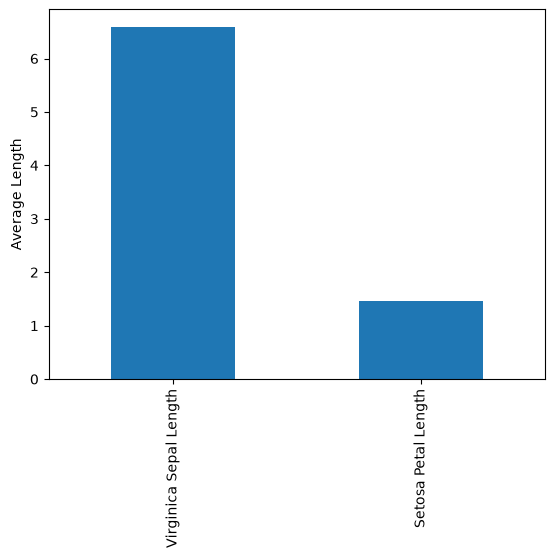

In [17]:
# code here
import matplotlib.pyplot as plt
avg=pd.Series([v['SepalLengthCm'].mean(),s['PetalLengthCm'].mean()],index=['Virginica Sepal Length', 'Setosa Petal Length'])
avg.plot(kind='bar')
plt.ylabel('Average Length')
plt.show()

### `Q-10:` Create the complete dataset by uisng the below datasets:
- virginica
- versicolor
- setosa
- sepal all
- petal all

This dataset should have these below column names in order:
1. Id
2. Species
3. SepalLengthCm
4. SepalWidthCm
5. PetalLengthCm
6. PetalWidthCm

Also, the dataset should be shuffled means the `Id` column should not be in increasing or decreasing order. So, make a dataset which has the shuffled Id column. You can use `DataFrame.sample()` method to shuffle.

In [ ]:
# code here
df=pd.concat([versicolor[['Id','Species']],virginica[['Id','Species']],setosa[['Id','Species']]])

In [22]:
df_f=petal_all[['Id','PetalLengthCm','PetalWidthCm']].merge(sepal_all[['Id','SepalLengthCm','SepalWidthCm']],on='Id')

In [25]:
species=df.merge(df_f,on='Id')
species=species.sample(frac=1,random_state=42).reset_index(drop=True)
species

,Id,Species,PetalLengthCm,PetalWidthCm,SepalLengthCm,SepalWidthCm
0,124,Iris-virginica,4.9,1.8,6.3,2.7
1,69,Iris-versicolor,4.5,1.5,6.2,2.2
2,19,Iris-setosa,1.7,0.3,5.7,3.8
3,129,Iris-virginica,5.6,2.1,6.4,2.8
4,127,Iris-virginica,4.8,1.8,6.2,2.8
...,...,...,...,...,...,...
145,122,Iris-virginica,4.9,2.0,5.6,2.8
146,7,Iris-setosa,1.4,0.3,4.6,3.4
147,65,Iris-versicolor,3.6,1.3,5.6,2.9
148,143,Iris-virginica,5.1,1.9,5.8,2.7


### `Q-11:` Find out the maximum and minimum sepal width and petal width of Setosa and Versicolor. To do this:
- First create a dataset with merging the required datasets
- After that, use `groupby` to create groups based on the "Species" column.
- Then find out which are asked in this question.


The output should be like this:
```bash
Minimum Sepal width of Setosa is 2.3
Maximum Sepal width of Setosa is 4.4

**************************************************

Minimum Sepal width of Versicolor is 2.0
Maximum Sepal width of Versicolor is 3.4

**************************************************
```

In [ ]:
# code here
s=species.groupby('Species')

In [33]:
s.get_group('Iris-setosa')['SepalWidthCm'].max()

np.float64(4.4)

In [38]:
print(f'Minimum Sepal width of Setosa is : {s.get_group('Iris-setosa')['SepalWidthCm'].min()}')
print(f'Maximum Sepal width of Setosa is : {s.get_group('Iris-setosa')['SepalWidthCm'].max()}')

print(f'Minimum Sepal width of Versicolor is : {s.get_group('Iris-versicolor')['SepalWidthCm'].min()}')
print(f'Maximum Sepal width of Versicolor is : {s.get_group('Iris-versicolor')['SepalWidthCm'].max()}')


Minimum Sepal width of Setosa is : 2.3
Maximum Sepal width of Setosa is : 4.4
Minimum Sepal width of Versicolor is : 2.0
Maximum Sepal width of Versicolor is : 3.4
